['Stationcode', 'Locations', 'Lat', 'Lon', 'Capitalcity', 'State', 'Temperature', 'D.O', 'pH', 'Conductivity', 'B.O.D', 'Nitrate', 'Fecalcaliform', 'Totalcaliform', 'class']


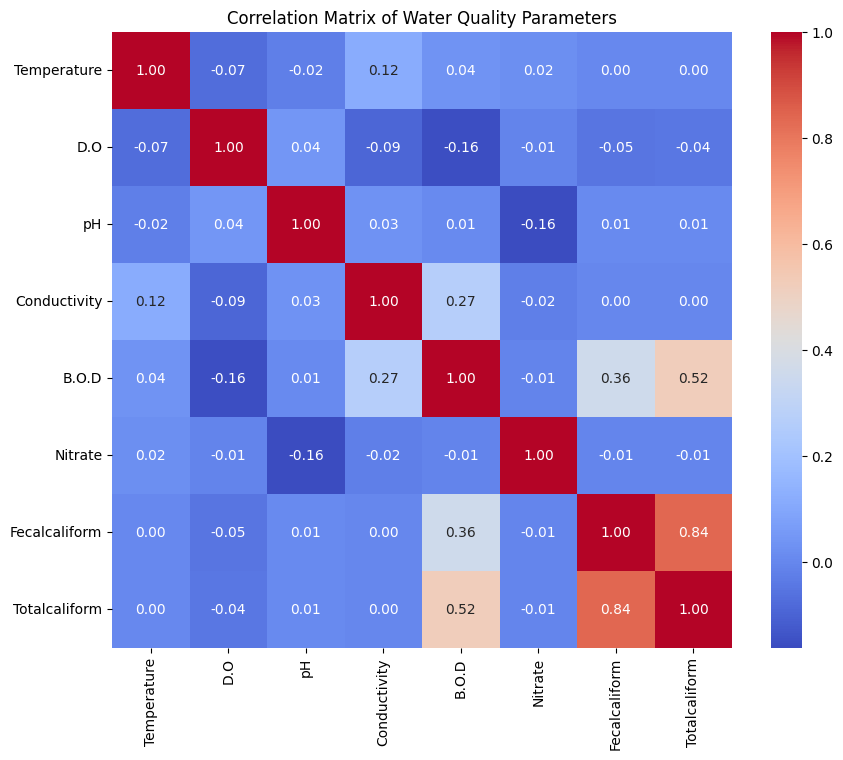

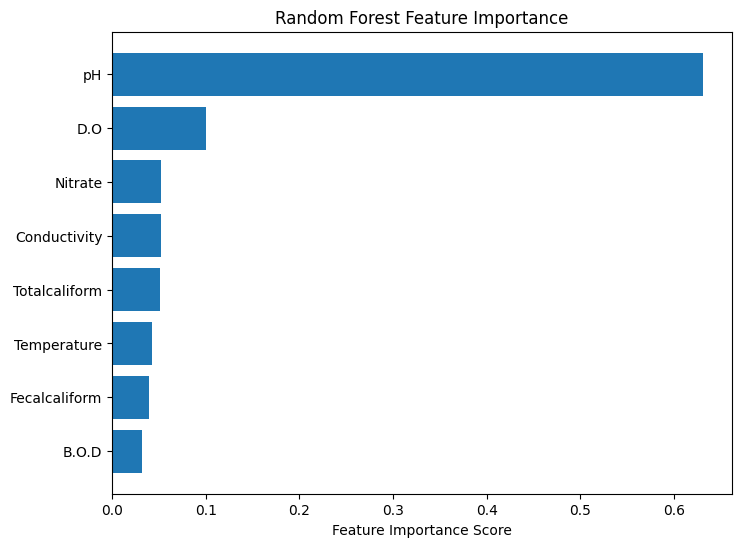

Accuracy: 0.967032967032967

Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      0.88      0.92        60
         1.0       0.97      0.99      0.98       213

    accuracy                           0.97       273
   macro avg       0.97      0.94      0.95       273
weighted avg       0.97      0.97      0.97       273


Confusion Matrix:
 [[ 53   7]
 [  2 211]]
Cross-validation scores: [0.91208791 0.9375     0.98897059 0.96323529 0.97794118]
Mean CV Accuracy: 0.9559469941822882
Logistic Regression Accuracy: 0.7912087912087912
SVM Accuracy: 0.7802197802197802
KNN Accuracy: 0.7765567765567766

Model Comparison:
                 Model  Accuracy
0        Random Forest  0.967033
1  Logistic Regression  0.791209
2                  SVM  0.780220
3                  KNN  0.776557


c:\Users\kavee\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


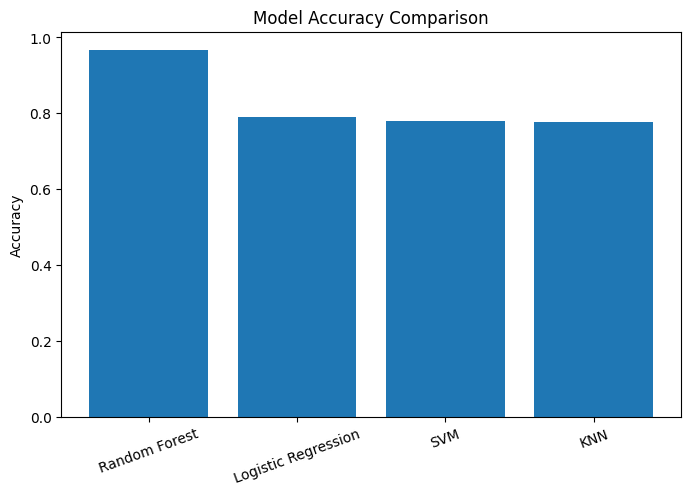


🔹 Testing subset: ['pH', 'D.O', 'Conductivity']
Accuracy: 0.967032967032967

🔹 Testing subset: ['Temperature', 'B.O.D', 'Nitrate']
Accuracy: 0.7875457875457875

🔹 Testing subset: ['pH', 'B.O.D']
Accuracy: 0.9706959706959707

🔹 Testing subset: ['pH', 'D.O', 'Nitrate', 'Fecalcaliform']
Accuracy: 0.9743589743589743

🔹 Testing subset: ['pH']
Accuracy: 0.978021978021978

🔹 Testing subset: ['Fecalcaliform']
Accuracy: 0.7692307692307693

🔹 Testing subset: ['D.O']
Accuracy: 0.8315018315018315

🔹 Testing subset: ['Totalcaliform']
Accuracy: 0.7655677655677655


In [40]:
# -*- coding: utf-8 -*-
"""Water Quality Analysis"""

import pandas as pd

df = pd.read_csv('aquaattributes.csv')
df.head()

print(df.columns.tolist())

# Drop columns that exist in the dataframe
columns_to_drop = ['Stationcode', 'Locations', 'Lat', 'Lon', 'Capitalcity', 'State', 'Unnamed: 15']
columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns_to_drop, axis=1)

df['class'] = df['class'].map({'yes': 1, 'no': 0})

df = df.apply(pd.to_numeric, errors='coerce')

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

features = ['Temperature', 'D.O', 'pH', 'Conductivity', 'B.O.D',
            'Nitrate', 'Fecalcaliform', 'Totalcaliform']

X = df[features]
y = df['class']

features = ['Temperature', 'D.O', 'pH', 'Conductivity', 'B.O.D',
            'Nitrate', 'Fecalcaliform', 'Totalcaliform']

X = df[features]
y = df['class']

import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix for your selected features
corr = X.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Water Quality Parameters")
plt.show()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

import matplotlib.pyplot as plt
import numpy as np

# Feature names
feature_names = X.columns
importances = rf.feature_importances_

# Sort features by importance
indices = np.argsort(importances)

plt.figure(figsize=(8, 6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Feature Importance Score")
plt.title("Random Forest Feature Importance")
plt.show()

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print("Cross-validation scores:", scores)
print("Mean CV Accuracy:", scores.mean())

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train, y_train)

log_pred = log_reg.predict(X_test)

from sklearn.metrics import accuracy_score

log_acc = accuracy_score(y_test, log_pred)
print("Logistic Regression Accuracy:", log_acc)

from sklearn.svm import SVC

svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_acc)

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)  # default = 5
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_acc)

import pandas as pd

results = {
    'Model': ['Random Forest', 'Logistic Regression', 'SVM', 'KNN'],
    'Accuracy': [accuracy_score(y_test, y_pred), log_acc, svm_acc, knn_acc]
}

results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.xticks(rotation=20)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

subset_1 = ['pH', 'D.O', 'Conductivity']                  # Strong chemical indicators
subset_2 = ['Temperature', 'B.O.D', 'Nitrate']           # Organic + nutrient indicators
subset_3 = ['pH', 'B.O.D']                               # Chemical + biological oxygen demand
subset_4 = ['pH', 'D.O', 'Nitrate', 'Fecalcaliform']     # Most powerful combination
subset_5 = ['pH']                                        # Single feature test
subset_6 = ['Fecalcaliform']                             # Single feature test
subset_7 = ['D.O']                                       # Single feature test
subset_8 = ['Totalcaliform']                             # Single feature test

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def test_feature_subset(feature_subset):
    print("\n🔹 Testing subset:", feature_subset)

    X_sub = df[feature_subset]
    y_sub = df['class']

    X_train, X_test, y_train, y_test = train_test_split(
        X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
    )

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    print("Accuracy:", acc)

    return acc

acc1 = test_feature_subset(subset_1)
acc2 = test_feature_subset(subset_2)
acc3 = test_feature_subset(subset_3)
acc4 = test_feature_subset(subset_4)
acc5 = test_feature_subset(subset_5)
acc6 = test_feature_subset(subset_6)
acc7 = test_feature_subset(subset_7)
acc8 = test_feature_subset(subset_8)

# Uncomment the line below if you have dataset1.csv
# new_df = pd.read_csv('dataset1.csv')


In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Select only the specific features
selected_features = ['pH', 'D.O']
X_new = df[selected_features]
y_new = df['class']

# 2. Split the data into training and testing sets
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=40, stratify=y_new
)

# 3. Create and Train the new model
# We use Random Forest as it generally performed well in your previous tests
rf_2feature = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_2feature.fit(X_train_new, y_train_new)

# 4. Make Predictions
y_pred_new = rf_2feature.predict(X_test_new)

# 5. Output Evaluation Metrics
print(f"--- Model Results using only {selected_features} ---")
print("Accuracy:", accuracy_score(y_test_new, y_pred_new))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_new, y_pred_new))
print("\nClassification Report:\n", classification_report(y_test_new, y_pred_new))

--- Model Results using only ['pH', 'D.O'] ---
Accuracy: 0.9523809523809523

Confusion Matrix:
 [[ 51   9]
 [  4 209]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.93      0.85      0.89        60
         1.0       0.96      0.98      0.97       213

    accuracy                           0.95       273
   macro avg       0.94      0.92      0.93       273
weighted avg       0.95      0.95      0.95       273



In [42]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- 1. Load Data ---
# Ensure 'aquaattributes.csv' is in your working directory
try:
    df = pd.read_csv('aquaattributes.csv')
    print("✅ Dataset loaded successfully.")
except FileNotFoundError:
    print("❌ Error: 'aquaattributes.csv' not found. Please upload the file.")

# --- 2. Preprocessing (Replicating your original logic) ---

# Drop unnecessary columns
columns_to_drop = ['Stationcode', 'Locations', 'Lat', 'Lon', 'Capitalcity', 'State', 'Unnamed: 15']
existing_cols_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(existing_cols_to_drop, axis=1)

# Convert target 'class' to numeric (1 = yes, 0 = no)
if df['class'].dtype == object:
    df['class'] = df['class'].map({'yes': 1, 'no': 0})

# Force all data to numeric (coercing errors to NaN)
df = df.apply(pd.to_numeric, errors='coerce')

# Impute missing values (NaN) with Median
imputer = SimpleImputer(strategy='median')
df_clean = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# --- 3. Feature Selection: pH and D.O ---
features = ['pH', 'D.O']
X = df_clean[features]
y = df_clean['class']

print(f"\nTraining data shape: {X.shape}")
print(f"Features used: {X.columns.tolist()}")

# --- 4. Train Model ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# --- 5. Evaluate ---
y_pred = rf_model.predict(X_test)

print("\n--- Model Performance (pH & D.O) ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

✅ Dataset loaded successfully.

Training data shape: (1361, 2)
Features used: ['pH', 'D.O']

--- Model Performance (pH & D.O) ---
Accuracy: 0.9743589743589743

Confusion Matrix:
 [[ 56   4]
 [  3 210]]


In [43]:
df

,Temperature,D.O,pH,Conductivity,B.O.D,Nitrate,Fecalcaliform,Totalcaliform,class
0,9.0,9.0,8.0,85.0,0.1,0.2,106.0,397.00,1
1,10.0,9.0,8.0,102.0,0.3,0.4,153.0,954.00,1
2,11.0,9.0,8.0,96.0,0.2,0.3,58.0,653.00,1
3,13.0,9.0,8.0,94.0,0.2,0.4,34.0,317.00,1
4,14.0,10.0,8.0,112.0,0.2,0.5,213.0,1072.00,1
...,...,...,...,...,...,...,...,...,...
1356,27.0,7.8,7.8,2391.0,4.0,9.0,19.0,0.55,1
1357,22.0,7.4,7.4,1737.0,19.0,6.0,12.0,0.93,1
1358,23.2,7.9,7.9,1054.0,8.5,30.0,213.0,2.15,1
1359,26.2,7.5,7.5,3616.0,11.0,3.0,5.5,0.76,1


In [44]:
# train_save_models.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer

# --- 1. Load and Clean Data ---
try:
    df = pd.read_csv('aquaattributes.csv')
    print("✅ Dataset loaded successfully.")
except FileNotFoundError:
    print("❌ Error: 'aquaattributes.csv' not found.")
    exit()

# Drop unnecessary columns
cols_to_drop = ['Stationcode', 'Locations', 'Lat', 'Lon', 'Capitalcity', 'State', 'Unnamed: 15']
df = df.drop([c for c in cols_to_drop if c in df.columns], axis=1)

# Map class and impute
df['class'] = df['class'].map({'yes': 1, 'no': 0})
df = df.apply(pd.to_numeric, errors='coerce')
imputer = SimpleImputer(strategy='median')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# --- 2. Define Features ---
all_features = ['Temperature', 'D.O', 'pH', 'Conductivity', 'B.O.D', 
                'Nitrate', 'Fecalcaliform', 'Totalcaliform']
X = df[all_features]
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 3. Model 1: All 8 Features ---
print("\nTraining Model 1 (All 8 Features)...")
rf_all = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_all.fit(X_train, y_train)
acc_8 = accuracy_score(y_test, rf_all.predict(X_test))

# --- 4. Determine Best Features ---
feature_imp = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf_all.feature_importances_
}).sort_values(by='Importance', ascending=False)

top_4_features = feature_imp['Feature'].head(4).tolist()
top_5_features = feature_imp['Feature'].head(5).tolist()

print(f"Top 4 Features: {top_4_features}")

# --- 5. Model 2: Best 4 Features ---
print("Training Model 2 (Best 4 Features)...")
X_4 = df[top_4_features]
X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(X_4, y, test_size=0.2, random_state=42, stratify=y)

rf_4 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_4.fit(X_train_4, y_train_4)
acc_4 = accuracy_score(y_test_4, rf_4.predict(X_test_4))

# --- 6. Model 3: Best 5 Features ---
print("Training Model 3 (Best 5 Features)...")
X_5 = df[top_5_features]
X_train_5, X_test_5, y_train_5, y_test_5 = train_test_split(X_5, y, test_size=0.2, random_state=42, stratify=y)

rf_5 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_5.fit(X_train_5, y_train_5)
acc_5 = accuracy_score(y_test_5, rf_5.predict(X_test_5))

# --- 7. Save Models ---
print("\nSaving models to .joblib files...")

# Save Model 1
joblib.dump({'model': rf_all, 'features': all_features}, 'water_quality_rf_8_features.joblib')

# Save Model 2
joblib.dump({'model': rf_4, 'features': top_4_features}, 'water_quality_rf_best_4.joblib')

# Save Model 3
joblib.dump({'model': rf_5, 'features': top_5_features}, 'water_quality_rf_best_5.joblib')

print(f"✅ Models Saved:\n 1. 8 Features (Acc: {acc_8:.4f})\n 2. Best 4 Features (Acc: {acc_4:.4f})\n 3. Best 5 Features (Acc: {acc_5:.4f})")

✅ Dataset loaded successfully.

Training Model 1 (All 8 Features)...
Top 4 Features: ['pH', 'D.O', 'Nitrate', 'Conductivity']
Training Model 2 (Best 4 Features)...
Training Model 3 (Best 5 Features)...

Saving models to .joblib files...
✅ Models Saved:
 1. 8 Features (Acc: 0.9670)
 2. Best 4 Features (Acc: 0.9707)
 3. Best 5 Features (Acc: 0.9634)


In [45]:
# save_ph_do_model.py
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

# --- 1. Load Data ---
try:
    df = pd.read_csv('aquaattributes.csv')
    print("✅ Dataset loaded successfully.")
except FileNotFoundError:
    print("❌ Error: 'aquaattributes.csv' not found.")
    exit()

# --- 2. Preprocessing ---
# Drop unnecessary columns
cols_to_drop = ['Stationcode', 'Locations', 'Lat', 'Lon', 'Capitalcity', 'State', 'Unnamed: 15']
df = df.drop([c for c in cols_to_drop if c in df.columns], axis=1)

# Map class (yes/no -> 1/0)
if df['class'].dtype == object:
    df['class'] = df['class'].map({'yes': 1, 'no': 0})

# Force numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Impute missing values
imputer = SimpleImputer(strategy='median')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# --- 3. Feature Selection (ONLY pH and D.O) ---
features = ['pH', 'D.O']
X = df[features]
y = df['class']

print(f"Features selected: {features}")

# --- 4. Train Model ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Random Forest on pH & D.O...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# --- 5. Evaluate ---
acc = accuracy_score(y_test, rf_model.predict(X_test))
print(f"Model Accuracy: {acc:.4f}")

# --- 6. Save Model ---
model_filename = 'water_quality_ph_do.joblib'
joblib.dump({
    'model': rf_model,
    'features': features
}, model_filename)

print(f"✅ Model saved successfully as '{model_filename}'")

✅ Dataset loaded successfully.
Features selected: ['pH', 'D.O']
Training Random Forest on pH & D.O...
Model Accuracy: 0.9744
✅ Model saved successfully as 'water_quality_ph_do.joblib'


In [46]:
# use_ph_do_model.py
import joblib
import pandas as pd
import numpy as np

# 1. Load the saved model
filename = 'water_quality_ph_do.joblib'
try:
    data = joblib.load(filename)
    model = data['model']
    features = data['features']
    print(f"🔹 Model Loaded. Expecting inputs: {features}")
except FileNotFoundError:
    print(f"❌ Error: {filename} not found. Run the save script first.")
    exit()
'''
# 2. Define new data (Example: Neutral pH and Good Oxygen)
# You can change these numbers to test different scenarios
new_water_sample = {
    'pH': [7.5],   # Normal range is 6.5 - 8.5
    'D.O': [6.0]   # Higher is generally better (>4 is usually okay)
}

# 3. Predict
input_df = pd.DataFrame(new_water_sample)
prediction = model.predict(input_df)[0]
probability = model.predict_proba(input_df)[0]

status = "SAFE (Potable)" if prediction == 1 else "UNSAFE (Not Potable)"
confidence = probability[prediction] * 100

print(f"\n--- Prediction Results ---")
print(f"Input Data: {new_water_sample}")
print(f"Result: {status}")
print(f"Confidence: {confidence:.2f}%")'''

🔹 Model Loaded. Expecting inputs: ['pH', 'D.O']


'\n# 2. Define new data (Example: Neutral pH and Good Oxygen)\n# You can change these numbers to test different scenarios\nnew_water_sample = {\n    \'pH\': [7.5],   # Normal range is 6.5 - 8.5\n    \'D.O\': [6.0]   # Higher is generally better (>4 is usually okay)\n}\n\n# 3. Predict\ninput_df = pd.DataFrame(new_water_sample)\nprediction = model.predict(input_df)[0]\nprobability = model.predict_proba(input_df)[0]\n\nstatus = "SAFE (Potable)" if prediction == 1 else "UNSAFE (Not Potable)"\nconfidence = probability[prediction] * 100\n\nprint(f"\n--- Prediction Results ---")\nprint(f"Input Data: {new_water_sample}")\nprint(f"Result: {status}")\nprint(f"Confidence: {confidence:.2f}%")'

In [47]:
import pandas as pd

# Load the new dataset
df_new = pd.read_csv('Water_Quality_Labeled_Training_Data.csv')

# Display first few rows
print(df_new.head())

# Check the distribution of the target 'class'
print("\nClass Counts:")
print(df_new['class'].value_counts()) 
# Result: 1    500 (All are potable)


df_new_2 = df_new[['pH', 'D.O','class']]
df_new_2.head()

   Sample ID    pH  Temperature  D.O  Conductivity  class
0          1  7.25         23.1  7.8           342      1
1          2  7.11         22.3  6.2           335      1
2          3  7.03         21.5  8.3           356      1
3          4  7.38         22.9  9.5           327      1
4          5  7.45         20.7  8.1           352      1

Class Counts:
class
1    500
Name: count, dtype: int64


,pH,D.O,class
0,7.25,7.8,1
1,7.11,6.2,1
2,7.03,8.3,1
3,7.38,9.5,1
4,7.45,8.1,1


In [48]:
import joblib
import pandas as pd
import numpy as np

# 1. Load the saved model
filename = 'water_quality_ph_do.joblib'
try:
    data = joblib.load(filename)
    model = data['model']
    features = data['features']
    print(f"🔹 Model Loaded. Expecting inputs: {features}")
except FileNotFoundError:
    print(f"❌ Error: {filename} not found. Run the save script first.")
    exit()

# 2. Prepare input data from df_new_2
# df_new_2 should contain 'pH' and 'D.O' columns
input_data = df_new_2[features]

print(f"\nInput shape: {input_data.shape}")
print(f"First few rows:\n{input_data.head()}")

# 3. Make predictions
predictions = model.predict(input_data)
probabilities = model.predict_proba(input_data)

# 4. Display results
print(f"\n--- Prediction Results ---")
print(f"Total samples: {len(predictions)}")
print(f"Potable (1): {np.sum(predictions == 1)}")
print(f"Not Potable (0): {np.sum(predictions == 0)}")

# 5. Add predictions to dataframe
df_new_2['prediction'] = predictions
df_new_2['confidence'] = np.max(probabilities, axis=1)

print(f"\nResults with confidence:\n{df_new_2.head(10)}")

# 6. Summary statistics
print(f"\nAverage Confidence: {df_new_2['confidence'].mean():.4f}")

🔹 Model Loaded. Expecting inputs: ['pH', 'D.O']

Input shape: (500, 2)
First few rows:
     pH  D.O
0  7.25  7.8
1  7.11  6.2
2  7.03  8.3
3  7.38  9.5
4  7.45  8.1

--- Prediction Results ---
Total samples: 500
Potable (1): 500
Not Potable (0): 0

Results with confidence:
     pH  D.O  class  prediction  confidence
0  7.25  7.8      1         1.0    0.999333
1  7.11  6.2      1         1.0    0.999565
2  7.03  8.3      1         1.0    1.000000
3  7.38  9.5      1         1.0    1.000000
4  7.45  8.1      1         1.0    1.000000
5  6.89  7.2      1         1.0    0.999438
6  7.19  8.8      1         1.0    1.000000
7  6.98  6.9      1         1.0    0.998890
8  7.31  8.4      1         1.0    1.000000
9  7.02  7.5      1         1.0    0.999762

Average Confidence: 0.9893


C:\Users\kavee\AppData\Local\Temp\ipykernel_20768\1642205266.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new_2['prediction'] = predictions
C:\Users\kavee\AppData\Local\Temp\ipykernel_20768\1642205266.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new_2['confidence'] = np.max(probabilities, axis=1)


In [49]:
# Display the first 5 rows to verify cleaning and imputation
print(df.head())

# Optional: Check the data types to ensure everything is numeric
print("\nData Types:")
print(df.dtypes)

   Temperature   D.O   pH  Conductivity  B.O.D  Nitrate  Fecalcaliform  \
0          9.0   9.0  8.0          85.0    0.1      0.2          106.0   
1         10.0   9.0  8.0         102.0    0.3      0.4          153.0   
2         11.0   9.0  8.0          96.0    0.2      0.3           58.0   
3         13.0   9.0  8.0          94.0    0.2      0.4           34.0   
4         14.0  10.0  8.0         112.0    0.2      0.5          213.0   

   Totalcaliform  class  
0          397.0    1.0  
1          954.0    1.0  
2          653.0    1.0  
3          317.0    1.0  
4         1072.0    1.0  

Data Types:
Temperature      float64
D.O              float64
pH               float64
Conductivity     float64
B.O.D            float64
Nitrate          float64
Fecalcaliform    float64
Totalcaliform    float64
class            float64
dtype: object


In [50]:
df['class'].value_counts()

class
1.0    1063
0.0     298
Name: count, dtype: int64

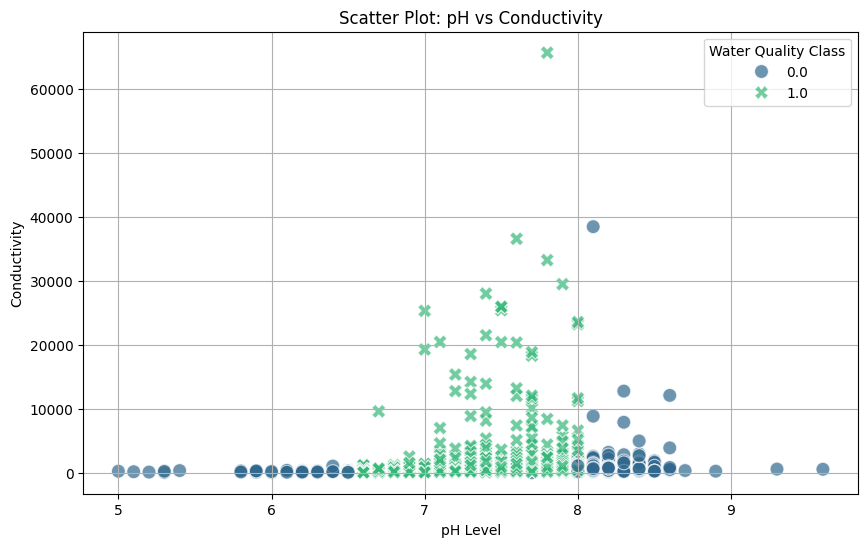

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(10, 6))

# Create the scatter plot
# You can change x='pH' and y='D.O' to any other columns in your features list
sns.scatterplot(data=df, x='pH', y='Conductivity', hue='class', palette='viridis', style='class', s=100, alpha=0.7)

plt.title('Scatter Plot: pH vs Conductivity')
plt.xlabel('pH Level')
plt.ylabel('Conductivity')
plt.legend(title='Water Quality Class', loc='upper right')
plt.grid(True)
plt.show()

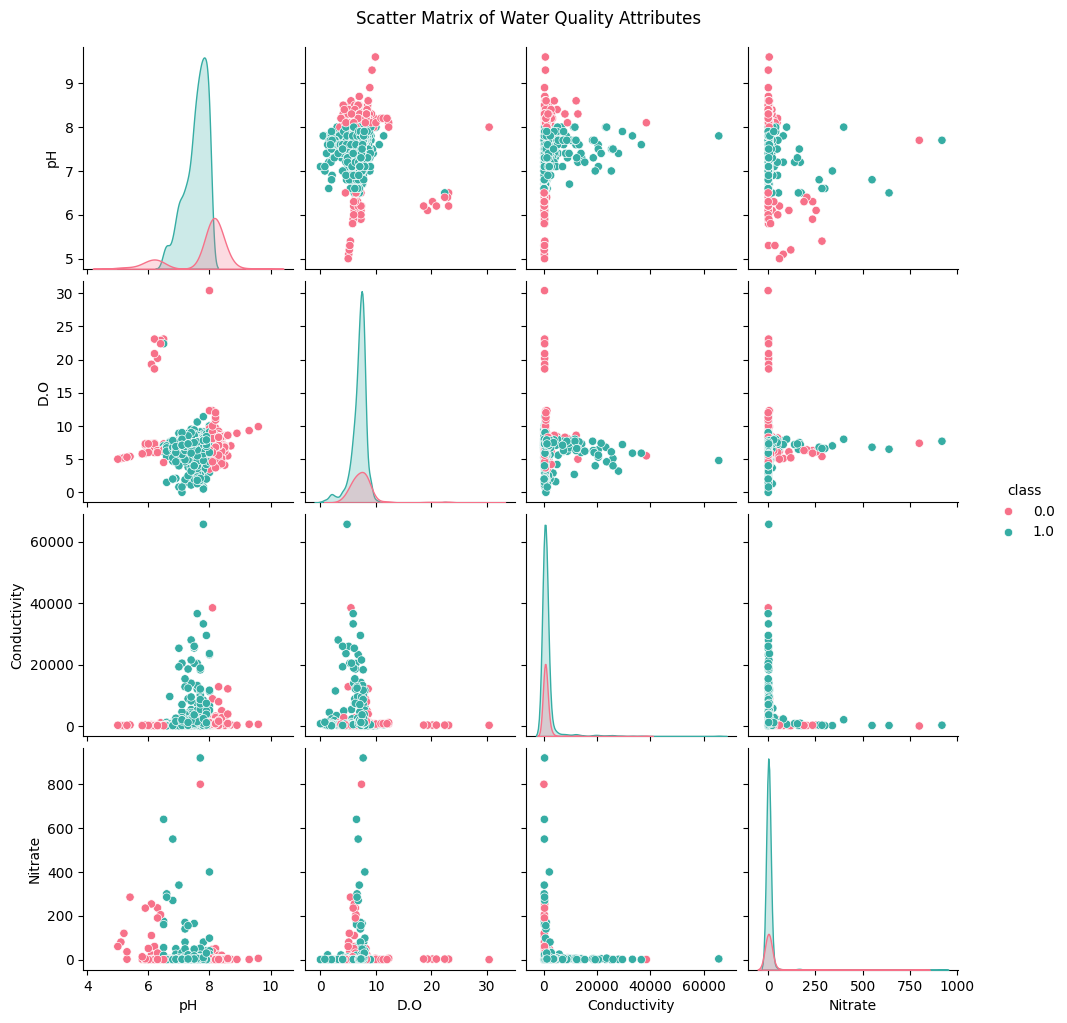

In [52]:
# Select a few main features to avoid overcrowding the plot
selected_features_for_plot = ['pH', 'D.O', 'Conductivity', 'Nitrate', 'class']

# Create the pairplot
sns.pairplot(df[selected_features_for_plot], hue='class', palette='husl', diag_kind='kde')
plt.suptitle("Scatter Matrix of Water Quality Attributes", y=1.02)
plt.show()

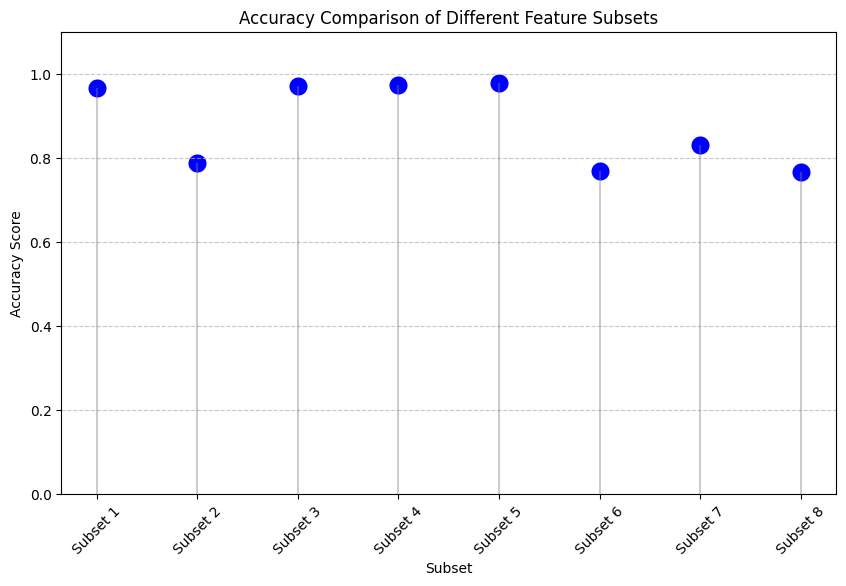

In [53]:
# Create a dictionary of your results
subset_results = {
    'Subset': ['Subset 1', 'Subset 2', 'Subset 3', 'Subset 4', 'Subset 5', 'Subset 6', 'Subset 7', 'Subset 8'],
    'Accuracy': [acc1, acc2, acc3, acc4, acc5, acc6, acc7, acc8]
}

# Convert to DataFrame
df_subsets = pd.DataFrame(subset_results)

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_subsets, x='Subset', y='Accuracy', s=200, color='blue', marker='o')

# Draw lines to make it easier to read (Lollipop chart style)
plt.vlines(x=df_subsets['Subset'], ymin=0, ymax=df_subsets['Accuracy'], color='grey', alpha=0.4)

plt.title("Accuracy Comparison of Different Feature Subsets")
plt.ylabel("Accuracy Score")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 1.1)  # Set y-axis limits to 0-1 range
plt.show()

8 features

best 4 features

best 5 features

Model 1 (All 8 Features) Accuracy: 0.9670

Feature Rankings:
          Feature  Importance
2             pH    0.630722
1            D.O    0.100741
5        Nitrate    0.051826
3   Conductivity    0.051744
7  Totalcaliform    0.050915
0    Temperature    0.042562
6  Fecalcaliform    0.039894
4          B.O.D    0.031596

Best 4 Features: ['pH', 'D.O', 'Nitrate', 'Conductivity']
Best 5 Features: ['pH', 'D.O', 'Nitrate', 'Conductivity', 'Totalcaliform']
Model 2 (Best 4 Features) Accuracy: 0.9707
Model 3 (Best 5 Features) Accuracy: 0.9634


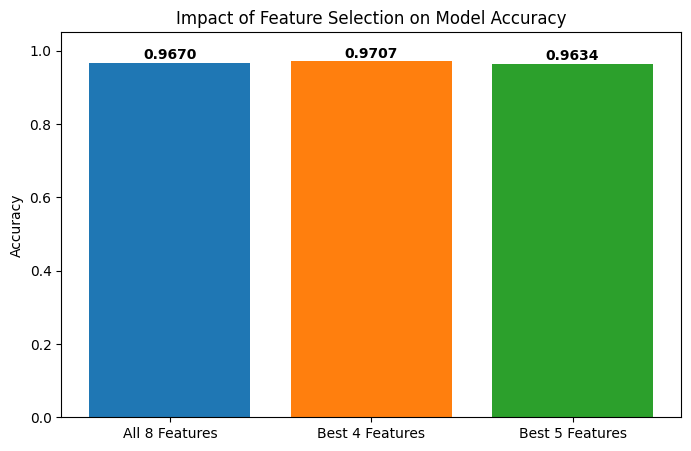

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Define All 8 Features
all_features = ['Temperature', 'D.O', 'pH', 'Conductivity', 'B.O.D', 
                'Nitrate', 'Fecalcaliform', 'Totalcaliform']

X = df[all_features]
y = df['class']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ---------------------------------------------------------
# MODEL 1: ALL 8 FEATURES
# ---------------------------------------------------------
rf_all = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_all.fit(X_train, y_train)
y_pred_all = rf_all.predict(X_test)
acc_8 = accuracy_score(y_test, y_pred_all)

print(f"Model 1 (All 8 Features) Accuracy: {acc_8:.4f}")

# ---------------------------------------------------------
# GET FEATURE IMPORTANCE TO FIND THE "BEST"
# ---------------------------------------------------------
# Create a dataframe to sort features by importance
feature_imp = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf_all.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Rankings:\n", feature_imp)

# Extract the names of the top features
top_4_features = feature_imp['Feature'].head(4).tolist()
top_5_features = feature_imp['Feature'].head(5).tolist()

print(f"\nBest 4 Features: {top_4_features}")
print(f"Best 5 Features: {top_5_features}")

# ---------------------------------------------------------
# MODEL 2: BEST 4 FEATURES
# ---------------------------------------------------------
X_4 = df[top_4_features]
X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(X_4, y, test_size=0.2, random_state=42, stratify=y)

rf_4 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_4.fit(X_train_4, y_train_4)
acc_4 = accuracy_score(y_test_4, rf_4.predict(X_test_4))

print(f"Model 2 (Best 4 Features) Accuracy: {acc_4:.4f}")

# ---------------------------------------------------------
# MODEL 3: BEST 5 FEATURES
# ---------------------------------------------------------
X_5 = df[top_5_features]
X_train_5, X_test_5, y_train_5, y_test_5 = train_test_split(X_5, y, test_size=0.2, random_state=42, stratify=y)

rf_5 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_5.fit(X_train_5, y_train_5)
acc_5 = accuracy_score(y_test_5, rf_5.predict(X_test_5))

print(f"Model 3 (Best 5 Features) Accuracy: {acc_5:.4f}")

# ---------------------------------------------------------
# FINAL COMPARISON PLOT
# ---------------------------------------------------------
results = pd.DataFrame({
    'Model': ['All 8 Features', 'Best 4 Features', 'Best 5 Features'],
    'Accuracy': [acc_8, acc_4, acc_5]
})

plt.figure(figsize=(8,5))
plt.bar(results['Model'], results['Accuracy'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylabel("Accuracy")
plt.title("Impact of Feature Selection on Model Accuracy")
plt.ylim(0, 1.05) # Set y-axis to show 0 to 1 scale
for i, v in enumerate(results['Accuracy']):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

In [55]:
import joblib

# 1. Save Model 1 (All 8 Features)
joblib.dump({
    'model': rf_all,
    'features': all_features
}, 'water_quality_rf_8_features.joblib')

# 2. Save Model 2 (Best 4 Features)
joblib.dump({
    'model': rf_4,
    'features': top_4_features
}, 'water_quality_rf_best_4.joblib')

# 3. Save Model 3 (Best 5 Features)
joblib.dump({
    'model': rf_5,
    'features': top_5_features
}, 'water_quality_rf_best_5.joblib')

print("✅ All 3 models saved successfully!")

✅ All 3 models saved successfully!


save Above 3 models

In [56]:
import joblib
import pandas as pd
import numpy as np

# --- STEP 1: LOAD THE MODEL ---
# Let's say we want to use the "Best 4 Features" model
loaded_data = joblib.load('water_quality_rf_best_4.joblib')

model = loaded_data['model']
required_features = loaded_data['features']

print(f"Model Loaded! This model expects these features: {required_features}")

# --- STEP 2: PREPARE NEW DATA ---
# Imagine this is new sensor data coming in (it might have extra columns)
new_sensor_data = {
    'Temperature': [30.5],
    'D.O': [6.5],
    'pH': [7.2],
    'Conductivity': [400],
    'B.O.D': [2.5],
    'Nitrate': [0.5],       # Extra column not needed by Best 4
    'Fecalcaliform': [100], # Extra column not needed by Best 4
    'Totalcaliform': [200]  # Extra column not needed by Best 4
}

new_df = pd.DataFrame(new_sensor_data)

# --- STEP 3: PREDICT ---
# Filter the dataframe to only include the features this specific model needs
input_data = new_df[required_features]

# Make prediction
prediction = model.predict(input_data)
probability = model.predict_proba(input_data)

print(f"\nPrediction (0=Unsafe, 1=Safe): {prediction[0]}")
print(f"Confidence: {np.max(probability)*100:.2f}%")

Model Loaded! This model expects these features: ['pH', 'D.O', 'Nitrate', 'Conductivity']

Prediction (0=Unsafe, 1=Safe): 1.0
Confidence: 99.19%


 recall or reuse this models

In [57]:
import pandas as pd

# 1. Load the original dataset
original_filename = 'merged_dataset.csv'
df = pd.read_csv(original_filename)

print("Original Data Loaded:")
print(f"Shape: {df.shape}")
print("Columns:", df.columns.tolist())
print(df.head())

# 2. Save this data set
saved_filename = 'merged_dataset_saved.csv'
df.to_csv(saved_filename, index=False)
print(f"\nDataset saved to {saved_filename}")

# 3. Load this data set
loaded_df = pd.read_csv(saved_filename)

print("\nReloaded Data:")
print(f"Shape: {loaded_df.shape}")
print(loaded_df.head())

Original Data Loaded:
Shape: (12647, 8)
Columns: ['pH', 'DO', 'BOD', 'Conductivity', 'Nitrate', 'Fecal_Coliform', 'Turbidity', 'Potability']
    pH    DO  BOD  Conductivity  Nitrate  Fecal_Coliform  Turbidity  \
0  8.0   9.0  0.1          85.0      0.2           106.0   3.258728   
1  8.0   9.0  0.3         102.0      0.4           153.0   3.745824   
2  8.0   9.0  0.2          96.0      0.3            58.0   1.984716   
3  8.0   9.0  0.2          94.0      0.4            34.0   2.885716   
4  8.0  10.0  0.2         112.0      0.5           213.0   1.548326   

   Potability  
0           1  
1           1  
2           1  
3           1  
4           1  

Dataset saved to merged_dataset_saved.csv

Reloaded Data:
Shape: (12647, 8)
    pH    DO  BOD  Conductivity  Nitrate  Fecal_Coliform  Turbidity  \
0  8.0   9.0  0.1          85.0      0.2           106.0   3.258728   
1  8.0   9.0  0.3         102.0      0.4           153.0   3.745824   
2  8.0   9.0  0.2          96.0      0.3      

In [58]:
import pandas as pd

# Load the dataset
filename = 'merged_dataset.csv'
df = pd.read_csv(filename)

# Select the requested columns
# Note: Mapping 'D.O' -> 'DO' and 'poterbilty' -> 'Potability' based on the file's actual headers
new_df_test= df[['pH', 'DO', 'Potability']].copy()

# Show result
print(new_df_test.head())

# Save to a new file

new_df_test.to_csv('ph_do_potability_subset.csv', index=False)

    pH    DO  Potability
0  8.0   9.0           1
1  8.0   9.0           1
2  8.0   9.0           1
3  8.0   9.0           1
4  8.0  10.0           1


In [59]:
import pandas as pd

# Load the original dataset
df = pd.read_csv('merged_dataset.csv')

# Select columns and rename 'Potability' to 'class'
new_df = df[['pH', 'DO', 'Potability']].rename(columns={'Potability': 'class'})

# Show result
print(new_df.head())

# Save to file
new_df.to_csv('ph_do_class_subset.csv', index=False)

    pH    DO  class
0  8.0   9.0      1
1  8.0   9.0      1
2  8.0   9.0      1
3  8.0   9.0      1
4  8.0  10.0      1


In [60]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the saved model
filename = 'water_quality_ph_do.joblib'
try:
    data = joblib.load(filename)
    model = data['model']
    features = data['features']
    print(f"🔹 Model Loaded. Expecting inputs: {features}")
except FileNotFoundError:
    print(f"❌ Error: {filename} not found. Run the save script first.")
    exit()

🔹 Model Loaded. Expecting inputs: ['pH', 'D.O']


In [61]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib

# 1. Load the dataset
df = pd.read_csv('aquaattributes.csv')

# 2. Define the expanded list of features
features = ['Temperature', 'D.O', 'pH', 'Conductivity', 'B.O.D', 'Nitrate', 'Fecalcaliform', 'Totalcaliform']

# 3. Clean up data: forcefully convert text/string columns to numeric
for col in ['Conductivity', 'Nitrate', 'Fecalcaliform']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows where our target 'class' is completely missing
df = df.dropna(subset=['class'])

# 4. Handle Missing Data
X = df[features].copy()
y = df['class'].copy()

# Fill any missing feature values with the median of their respective columns
X = X.fillna(X.median())

# 5. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Initialize and Train the Random Forest Model
new_model = RandomForestClassifier(n_estimators=100, random_state=42)
new_model.fit(X_train, y_train)

# 7. Evaluate the model
accuracy = new_model.score(X_test, y_test)
print(f"New Model Accuracy with 8 features: {accuracy * 100:.2f}%")

# 8. Save the updated model and the feature list
model_data = {
    'model': new_model,
    'features': features
}

filename = 'water_quality_multi_features.joblib'
joblib.dump(model_data, filename)
print(f"✅ Saved updated model to {filename}")

New Model Accuracy with 8 features: 96.70%
✅ Saved updated model to water_quality_multi_features.joblib


In [62]:
import joblib

# Load the NEW multi-feature model
filename = 'water_quality_multi_features.joblib'

data = joblib.load(filename)
model = data['model']
features = data['features']
print(f"🔹 Model Loaded. Expecting the following 8 inputs: \n{features}")

🔹 Model Loaded. Expecting the following 8 inputs: 
['Temperature', 'D.O', 'pH', 'Conductivity', 'B.O.D', 'Nitrate', 'Fecalcaliform', 'Totalcaliform']


For Subset_1 [pH, D.O, Conductivity]

In [63]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib

# 1. Load the dataset
df = pd.read_csv('aquaattributes.csv')

# 2. Define the exact subset of features you want
subset_1 = ['pH', 'D.O', 'Conductivity']

# 3. Clean up data: forcefully convert 'Conductivity' to numeric
df['Conductivity'] = pd.to_numeric(df['Conductivity'], errors='coerce')

# Drop rows where our target 'class' is completely missing
df = df.dropna(subset=['class'])

# 4. Handle Missing Data
X = df[subset_1].copy()
y = df['class'].copy()

# Fill any missing feature values with the median of their respective columns
X = X.fillna(X.median())

# 5. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Initialize and Train the Random Forest Model
new_model = RandomForestClassifier(n_estimators=100, random_state=42)
new_model.fit(X_train, y_train)

# 7. Evaluate the model
accuracy = new_model.score(X_test, y_test)
print(f"Model Accuracy with subset_1: {accuracy * 100:.2f}%")

# 8. Save the updated model and the feature list
model_data = {
    'model': new_model,
    'features': subset_1
}

filename = 'water_quality_subset_1.joblib'
joblib.dump(model_data, filename)
print(f"✅ Saved updated model to {filename}")

Model Accuracy with subset_1: 97.07%
✅ Saved updated model to water_quality_subset_1.joblib


In [64]:
import joblib

# Load the NEW subset model
filename = 'water_quality_subset_1.joblib'

data = joblib.load(filename)
model = data['model']
features = data['features']
print(f"🔹 Model Loaded. Expecting the following 3 inputs: \n{features}")

🔹 Model Loaded. Expecting the following 3 inputs: 
['pH', 'D.O', 'Conductivity']


Code for Checking Accuracy on New Data (With previously saved model and evaluates it on newly uploaded dataset)

In [65]:
import pandas as pd
import joblib

def check_new_data_accuracy(model_filename, new_dataset_filename):
    print("--------------------------------------------------")
    # 1. Load the existing model
    try:
        data = joblib.load(model_filename)
        model = data['model']
        features = data['features']
        print(f"🔹 Model Loaded successfully.")
        print(f"🔹 Expected Features: {features}")
    except FileNotFoundError:
        print(f"❌ Error: Model file '{model_filename}' not found.")
        return
    
    # 2. Load the new dataset
    try:
        df = pd.read_csv(new_dataset_filename)
        print(f"🔹 New Dataset '{new_dataset_filename}' Loaded. Total rows: {len(df)}")
    except FileNotFoundError:
        print(f"❌ Error: Dataset file '{new_dataset_filename}' not found.")
        return
        
    # 3. Preprocess the new data
    # Ensure all expected feature columns are numeric (handles cases where numbers are saved as text)
    for col in features:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        else:
            print(f"❌ Error: The new dataset is missing the required column: '{col}'")
            return
            
    # The dataset must have the 'class' column so we can compare predictions vs actuals
    if 'class' not in df.columns:
        print("❌ Error: The new dataset must contain a 'class' column to check accuracy.")
        return
        
    # Drop rows where the actual 'class' answer is missing
    df = df.dropna(subset=['class'])
    
    # Extract features (X) and target (y)
    X_new = df[features].copy()
    y_new = df['class'].copy()
    
    # Fill any missing feature values with the median (same strategy used in training)
    X_new = X_new.fillna(X_new.median())
    
    # 4. Calculate and print the accuracy
    accuracy = model.score(X_new, y_new)
    print(f"✅ Accuracy on the new dataset: {accuracy * 100:.2f}%")
    print("--------------------------------------------------")

In [66]:
# Example: Testing the subset model on a newly uploaded file
# Replace 'new_aquaattributes.csv' with the actual name of your uploaded file

check_new_data_accuracy(
    model_filename='water_quality_subset_1.joblib', 
    new_dataset_filename='new_aquaattributes.csv'
)

--------------------------------------------------
🔹 Model Loaded successfully.
🔹 Expected Features: ['pH', 'D.O', 'Conductivity']
❌ Error: Dataset file 'new_aquaattributes.csv' not found.


Code for the Advanced Evaluation Script new data sets

✅ Created 'mock_new_data.csv' for testing.
🔹 Model 'water_quality_subset_1.joblib' Loaded successfully.
🔹 Expected Features: ['pH', 'D.O', 'Conductivity']
🔹 Evaluating 200 rows from 'mock_new_data.csv'

📊 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

          no       1.00      0.84      0.91        43
         yes       0.96      1.00      0.98       157

    accuracy                           0.96       200
   macro avg       0.98      0.92      0.94       200
weighted avg       0.97      0.96      0.96       200

🎯 SUMMARY METRICS:
   Accuracy : 96.50%
   F1-Score : 0.9638
   Recall   : 0.9650

✅ Displaying the Confusion Matrix:


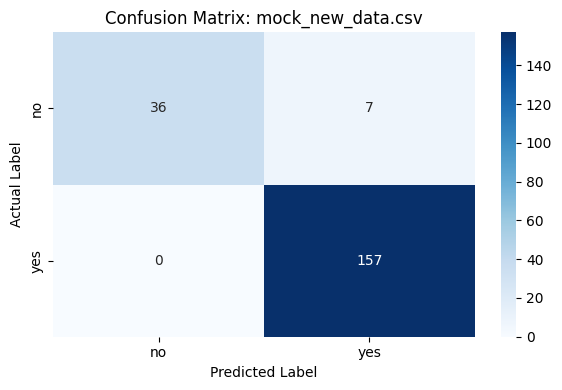

In [67]:
import pandas as pd

# 1. Create the mock_new_data.csv file by randomly sampling 200 rows from your original dataset
df = pd.read_csv('aquaattributes.csv')
df.sample(200, random_state=42).to_csv('mock_new_data.csv', index=False)
print("✅ Created 'mock_new_data.csv' for testing.")

# 2. Run the evaluation function on this newly created mock dataset
evaluate_new_data_advanced(
    model_filename='water_quality_subset_1.joblib', 
    new_dataset_filename='mock_new_data.csv'
)

In [68]:
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_new_data_advanced(model_filename, new_dataset_filename):
    print("==================================================")
    # 1. Load the existing model
    try:
        data = joblib.load(model_filename)
        model = data['model']
        features = data['features']
        print(f"🔹 Model '{model_filename}' Loaded successfully.")
        print(f"🔹 Expected Features: {features}")
    except FileNotFoundError:
        print(f"❌ Error: Model file '{model_filename}' not found.")
        return
    
    # 2. Load the new dataset
    try:
        df_new = pd.read_csv(new_dataset_filename)
    except FileNotFoundError:
        print(f"❌ Error: Dataset file '{new_dataset_filename}' not found.")
        return
        
    # 3. Preprocess the new data to match the model's expectations
    for col in features:
        if col in df_new.columns:
            # Force columns to be numeric, hiding text errors as NaN
            df_new[col] = pd.to_numeric(df_new[col], errors='coerce')
        else:
            print(f"❌ Error: The new dataset is missing the required column: '{col}'")
            return
            
    if 'class' not in df_new.columns:
        print("❌ Error: The new dataset must contain a 'class' column to check metrics.")
        return
        
    # Drop rows without actual labels and separate X (features) and y (target)
    df_new = df_new.dropna(subset=['class'])
    X_new = df_new[features].copy()
    y_new = df_new['class'].copy()
    
    # Fill missing feature data with the median
    X_new = X_new.fillna(X_new.median())
    
    print(f"🔹 Evaluating {len(X_new)} rows from '{new_dataset_filename}'")
    print("==================================================\n")
    
    # 4. Generate Predictions
    y_pred = model.predict(X_new)
    
    # 5. Print the Classification Report
    print("📊 CLASSIFICATION REPORT:")
    print(classification_report(y_new, y_pred))
    
    # 6. Calculate Summary Metrics (Weighted average handles multi-class and class imbalances)
    acc = accuracy_score(y_new, y_pred)
    f1 = f1_score(y_new, y_pred, average='weighted')
    recall = recall_score(y_new, y_pred, average='weighted')
    
    print("🎯 SUMMARY METRICS:")
    print(f"   Accuracy : {acc * 100:.2f}%")
    print(f"   F1-Score : {f1:.4f}")
    print(f"   Recall   : {recall:.4f}\n")
    
    # 7. Generate and Plot the Confusion Matrix
    print("✅ Displaying the Confusion Matrix:")
    cm = confusion_matrix(y_new, y_pred, labels=model.classes_)
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f'Confusion Matrix: {new_dataset_filename}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show() # Renders the plot directly in the notebook

In [69]:
# Example of testing the subset model on a new file:
evaluate_new_data_advanced(
    model_filename='water_quality_subset_1.joblib', 
    new_dataset_filename='your_new_file.csv'  # <-- Put your new file name here
)

🔹 Model 'water_quality_subset_1.joblib' Loaded successfully.
🔹 Expected Features: ['pH', 'D.O', 'Conductivity']
❌ Error: Dataset file 'your_new_file.csv' not found.


Statistical Hypothesis 

In [71]:
import pandas as pd
from scipy import stats

# 1. Load and clean the data
df = pd.read_csv('aquaattributes.csv')
df['Conductivity'] = pd.to_numeric(df['Conductivity'], errors='coerce')
df = df.dropna(subset=['Conductivity', 'class'])

# 2. Split Conductivity data into the two classes
cond_yes = df[df['class'] == 'yes']['Conductivity']
cond_no = df[df['class'] == 'no']['Conductivity']

# 3. Perform an Independent T-Test
t_stat, p_value = stats.ttest_ind(cond_yes, cond_no, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

# 4. Evaluate the Hypothesis
alpha = 0.05
print("-" * 30)
if p_value < alpha:
    print("✅ Conclusion: Reject the Null Hypothesis.")
    print("There IS a statistically significant difference in Conductivity between the two classes. Great feature choice!")
else:
    print("❌ Conclusion: Fail to reject the Null Hypothesis.")
    print("There is NO significant difference in Conductivity between the classes.")

T-statistic: 1.9971
P-value: 4.6186e-02
------------------------------
✅ Conclusion: Reject the Null Hypothesis.
There IS a statistically significant difference in Conductivity between the two classes. Great feature choice!


Hypothesis testing for pH and D.O

=== 1. Statistical Hypothesis Testing ===

Feature: pH
T-statistic: -4.8663
P-value:     1.7697e-06
✅ Conclusion: Reject Null Hypothesis. Significant difference exists.

Feature: D.O
T-statistic: -4.2261
P-value:     3.0642e-05
✅ Conclusion: Reject Null Hypothesis. Significant difference exists.

=== 2. Feature Importances ===
pH: 82.38%
D.O: 17.62%


C:\Users\kavee\AppData\Local\Temp\ipykernel_20768\529317420.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=features, y=importances, palette='viridis', order=['D.O', 'pH'])


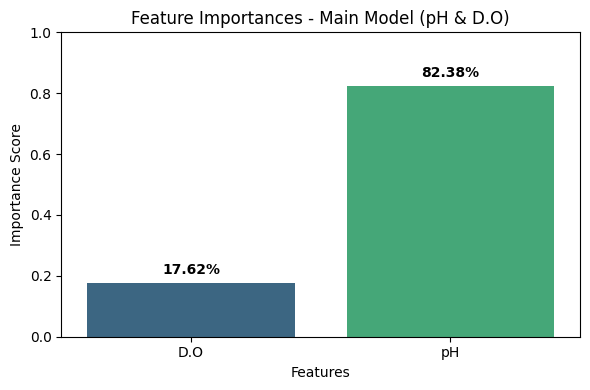

In [72]:
import pandas as pd
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv('aquaattributes.csv')
features = ['pH', 'D.O']
df = df.dropna(subset=features + ['class'])

# --- 1. Statistical Hypothesis Testing ---
yes_class = df[df['class'] == 'yes']
no_class = df[df['class'] == 'no']

print("=== 1. Statistical Hypothesis Testing ===")
alpha = 0.05
for f in features:
    t_stat, p_val = stats.ttest_ind(yes_class[f], no_class[f], equal_var=False)
    print(f"\nFeature: {f}")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value:     {p_val:.4e}")
    if p_val < alpha:
        print("✅ Conclusion: Reject Null Hypothesis. Significant difference exists.")
    else:
        print("❌ Conclusion: Fail to reject Null Hypothesis.")

# --- 2. Feature Importances ---
print("\n=== 2. Feature Importances ===")
X = df[features]
y = df['class']

# Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Extract and print importances
importances = model.feature_importances_
for f, imp in zip(features, importances):
    print(f"{f}: {imp*100:.2f}%")

# Create a Plot
plt.figure(figsize=(6, 4))
sns.barplot(x=features, y=importances, palette='viridis', order=['D.O', 'pH'])
plt.title('Feature Importances - Main Model (pH & D.O)')
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.ylim(0, 1)

# Add percentages on top of bars
for i, v in enumerate([importances[1], importances[0]]): # Sorting order
    plt.text(i, v + 0.02, f"{v*100:.2f}%", ha='center', va='bottom', fontweight='bold')
    
plt.tight_layout()
plt.show()

Hypothesis Testing for pH and Conductivity

In [73]:
import pandas as pd
from scipy import stats

# 1. Load Data
df = pd.read_csv('aquaattributes.csv')
features_to_test = ['pH', 'Conductivity']

# Clean Data (Convert Conductivity to numeric)
df['Conductivity'] = pd.to_numeric(df['Conductivity'], errors='coerce')
df = df.dropna(subset=features_to_test + ['class'])

# 2. Split classes
yes_class = df[df['class'] == 'yes']
no_class = df[df['class'] == 'no']

# 3. Perform the Independent T-Test
print("=== Statistical Hypothesis Testing ===")
alpha = 0.05
for f in features_to_test:
    t_stat, p_val = stats.ttest_ind(yes_class[f], no_class[f], equal_var=False)
    print(f"\nFeature: {f}")
    print(f"  T-statistic: {t_stat:.4f}")
    print(f"  P-value:     {p_val:.4e}")
    if p_val < alpha:
        print("  ✅ Conclusion: Reject Null Hypothesis. Significant difference exists.")
    else:
        print("  ❌ Conclusion: Fail to reject Null Hypothesis. NO significant difference.")

=== Statistical Hypothesis Testing ===

Feature: pH
  T-statistic: -4.4034
  P-value:     1.4582e-05
  ✅ Conclusion: Reject Null Hypothesis. Significant difference exists.

Feature: Conductivity
  T-statistic: 1.9772
  P-value:     4.8396e-02
  ✅ Conclusion: Reject Null Hypothesis. Significant difference exists.
